In [8]:
#load the dataset
import pandas as pd

In [9]:
emotions_df=pd.read_csv("/content/text.csv")

In [10]:
emotions_df.head()

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4.0
1,1,ive enjoyed being able to slouch about relax a...,0.0
2,2,i gave up my internship with the dmrg and am f...,4.0
3,3,i dont know i feel so lost,0.0
4,4,i am a kindergarten teacher and i am thoroughl...,4.0


In [11]:
hate_df=pd.read_csv("/content/labeled_data.csv")

In [12]:
hate_df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [13]:
#data preprocessing-dropping unwanted columns
emotions_df.drop(columns=['Unnamed: 0'],inplace=True)
hate_df.drop(columns=['Unnamed: 0','count','hate_speech','offensive_language','neither'],inplace=True)

In [14]:
hate_df.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [15]:
emotions_df.head()

,text,label
0,i just feel really helpless and heavy hearted,4.0
1,ive enjoyed being able to slouch about relax a...,0.0
2,i gave up my internship with the dmrg and am f...,4.0
3,i dont know i feel so lost,0.0
4,i am a kindergarten teacher and i am thoroughl...,4.0


In [16]:
emotions_df.columns, hate_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['class', 'tweet'], dtype='object'))

In [17]:
#renaming the columns
hate_df.rename(columns={'tweet':'text','class':'label'}, inplace=True)

In [18]:
emotions_df.columns, hate_df.columns

(Index(['text', 'label'], dtype='object'),
 Index(['label', 'text'], dtype='object'))

In [19]:
#checking for null values:
emotions_df.isnull().sum(), hate_df.isnull().sum()

(text     0
 label    1
 dtype: int64,
 label    0
 text     0
 dtype: int64)

In [20]:
emotions_df.shape, hate_df.shape

((311560, 2), (24783, 2))

In [21]:
#taking(extracting) 12 thousand rows from each datasets
emotions_df['label'].value_counts()


,count
label,
1.0,105452
0.0,90766
3.0,42705
4.0,35626
2.0,25754
5.0,11256


In [22]:
e_df = pd.DataFrame()
for i in range(6):
  subset = emotions_df[emotions_df['label'] == i].sample(n = 2000, random_state = 42)
  e_df = pd.concat([e_df, subset])

In [23]:
e_df.shape

(12000, 2)

In [24]:
emotions_df = e_df.copy()

In [25]:
emotions_df['label'].value_counts()

,count
label,
0.0,2000
1.0,2000
2.0,2000
3.0,2000
4.0,2000
5.0,2000


In [26]:
hate_df['label'].value_counts()

,count
label,
1,19190
2,4163
0,1430


In [27]:
offensive_speech = hate_df[hate_df['label'] == 1].sample(n = 6407, random_state = 42)
hate_df = hate_df[hate_df['label'] != 1]

In [28]:
hate_df.shape

(5593, 2)

In [29]:
hate_df = pd.concat([offensive_speech, hate_df], axis = 0)

In [30]:
hate_df.shape

(12000, 2)

In [31]:
emotions_df.shape, hate_df.shape

((12000, 2), (12000, 2))

In [32]:
emotions_df.head(3)

,text,label
71898,i feel somehow abused,0.0
156790,i feel like such a failure and quite idiotic,0.0
131442,i just suddenly feel that everything was fake,0.0


In [33]:
hate_df.head(3)

,label,text
22889,1,Why is it everytime I go to cracker barrel the...
20565,1,"Run that nigga, you don't want that nigga, but..."
10780,1,I need a girl from Jamaica I can't fuck with t...


In [34]:
#resetting the indexes
emotions_df.reset_index(drop = True, inplace = True)
hate_df.reset_index(drop = True, inplace = True)

In [35]:
emotions_df.head(3)

,text,label
0,i feel somehow abused,0.0
1,i feel like such a failure and quite idiotic,0.0
2,i just suddenly feel that everything was fake,0.0


In [36]:
hate_df.head(3)

,label,text
0,1,Why is it everytime I go to cracker barrel the...
1,1,"Run that nigga, you don't want that nigga, but..."
2,1,I need a girl from Jamaica I can't fuck with t...


In [37]:
#stopwords removal
import warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [38]:
!pip install tensorflow

In [39]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [40]:
#loading the stopwords
stop_words = set(stopwords.words('english'))

In [41]:
len(stop_words)

198

In [42]:
print(stop_words)

{'m', 'was', 'do', 'but', 'after', 'ain', 'haven', "don't", 'isn', 'through', 'most', 'by', 'there', "it'll", 'himself', "she'll", 'now', 'same', 'when', 'll', 'this', 'yours', 'having', 'is', 'these', 'shouldn', 'below', 'which', 'you', 'own', 'them', 'of', "i'd", "needn't", 'all', 'at', 'wasn', 'down', 'to', 'mustn', "she's", 'are', 'had', 'needn', "it's", 'or', 'ourselves', "that'll", "they've", "weren't", 'under', 'again', 'whom', 'y', "they'd", 'were', 'yourselves', 'your', 'some', 'off', 'itself', "wasn't", 'what', 'more', 'will', 'she', 'into', 'should', 'o', "they'll", "he'd", "didn't", "doesn't", 'hers', "shan't", 'then', 'it', 'before', "you'll", "i'm", 'above', 'my', 't', 'ours', 'me', 'myself', 's', "you've", 'their', 'here', 'him', 'if', 'only', 're', 'other', 'too', 'until', "shouldn't", "couldn't", 'in', "haven't", 'about', "should've", "we're", 'during', 'have', 'any', "mustn't", 'very', "you're", 'being', "he's", 'aren', 'further', 'few', 'couldn', 'hasn', 'that', 'wer

In [43]:
#stopwords removal function
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if not isinstance(text, str):   # handle NaN or non-string
        return ""
    all_words = text.split()        # split by whitespace instead of word_tokenize
    filtered_words = [word for word in all_words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Apply to DataFrames
emotions_df['text'] = emotions_df['text'].apply(remove_stopwords)
hate_df['text'] = hate_df['text'].apply(remove_stopwords)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [44]:
emotions_df.head(3)

,text,label
0,feel somehow abused,0.0
1,feel like failure quite idiotic,0.0
2,suddenly feel everything fake,0.0


In [45]:
hate_df.head(3)

,label,text
0,1,everytime go cracker barrel girl great tits se...
1,1,"Run nigga, want nigga, need bad bitch that's h..."
2,1,need girl Jamaica can't fuck basic black bitches


In [46]:
#tokenization and padding
tokenizer = Tokenizer()
tokenizer.fit_on_texts(pd.concat([emotions_df['text'], hate_df['text']]))

In [47]:
emotion_sequences = tokenizer.texts_to_sequences(emotions_df['text'])
hate_sequences = tokenizer.texts_to_sequences(hate_df['text'])

In [48]:
emotions_df['text'].iloc[2]

'suddenly feel everything fake'

In [49]:
emotion_sequences[2:3]

[[918, 1, 132, 414]]

In [50]:
max_length = 50
emotion_padded = pad_sequences(emotion_sequences, maxlen = max_length, padding = 'post')
hate_padded = pad_sequences(hate_sequences, maxlen = max_length, padding = 'post')

In [51]:
emotion_padded[2:3]

array([[918,   1, 132, 414,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]],
      dtype=int32)

In [52]:
#generating labels in numpy array format
import numpy as np
emotion_labels = np.array(emotions_df['label'])
hate_labels = np.array(hate_df['label'])

In [53]:
#model evaluation:
#prepare seperate inputs for each dataset
emotion_input = emotion_padded
hate_input = hate_padded

In [54]:
#defining multiple input layers for each task
emotion_input_layer = keras.layers.Input(shape = (max_length,), name = 'emotion_input')
hate_input_layer = keras.layers.Input(shape = (max_length,), name = 'hate_input')

In [55]:
#use as Shared embedding layer
embedding_layer = keras.layers.Embedding(input_dim = len(tokenizer.word_index) + 1, output_dim = 128)

In [56]:
#APPLY THE EMBEDDING LAYER TO EACH INPUT
emotion_embedding = embedding_layer(emotion_input_layer)
hate_embedding = embedding_layer(hate_input_layer)

In [57]:
#shared LSTM layer
shared_lstm = keras.layers.LSTM(64, return_sequences = True)

In [58]:
emotion_lstm = shared_lstm(emotion_embedding)
hate_lstm = shared_lstm(hate_embedding)

In [59]:
#shared global average pooling layer and dropout layer
shared_pooling = keras.layers.GlobalAveragePooling1D()
shared_dropout = keras.layers.Dropout(0.5)

In [60]:
emotion_features = shared_dropout(shared_pooling(emotion_lstm))
hate_features = shared_dropout(shared_pooling(hate_lstm))

In [61]:
len(emotions_df['label'].unique()),  len(hate_df['label'].unique())

(6, 3)

In [62]:
#output layers
emotion_output = keras.layers.Dense(6, activation = 'softmax', name = 'emotion_output')(emotion_features)
hate_output = keras.layers.Dense(3, activation = 'softmax', name = 'hate_output')(hate_features)

In [63]:
#compile the model with multiple inputs and outputs
model = keras.models.Model(inputs = [emotion_input_layer, hate_input_layer],
                           outputs = [emotion_output, hate_output])

model.compile(optimizer = 'adam',
              loss = {
                  'emotion_output' : 'sparse_categorical_crossentropy',
                  'hate_output' : 'sparse_categorical_crossentropy'
              },
              metrics = {
                  'emotion_output': 'accuracy',
                  'hate_output':'accuracy'
              })

In [64]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emotion_input       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hate_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  4,102,016 │ emotion_input[0]… │
│ (Embedding)         │                   │            │ hate_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50, 64)    │     49,408 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ lstm[0][0],       │
│ (GlobalAveragePool… │                   │            │ lstm[1][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ global_average_p… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_output      │ (None, 6)         │        390 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hate_output (Dense) │ (None, 3)         │        195 │ dropout[1][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,152,009 (15.84 MB)

 Trainable params: 4,152,009 (15.84 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
#training the model with sepearte inputs
model.fit(x = {'emotion_input' : emotion_input,
               'hate_input' : hate_input},
          y = {'emotion_output' : emotion_labels,
               'hate_output' : hate_labels},
          epochs = 10,
          batch_size = 4)

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 127s 42ms/step - emotion_output_accuracy: 0.3728 - emotion_output_loss: 1.4513 - hate_output_accuracy: 0.7782 - hate_output_loss: 0.6020 - loss: 2.0533
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 137s 40ms/step - emotion_output_accuracy: 0.8808 - emotion_output_loss: 0.4136 - hate_output_accuracy: 0.8825 - hate_output_loss: 0.3364 - loss: 0.7500
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 138s 38ms/step - emotion_output_accuracy: 0.9424 - emotion_output_loss: 0.1837 - hate_output_accuracy: 0.9392 - hate_output_loss: 0.1846 - loss: 0.3683
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 117s 39ms/step - emotion_output_accuracy: 0.9646 - emotion_output_loss: 0.1118 - hate_output_accuracy: 0.9724 - hate_output_loss: 0.0886 - loss: 0.2004
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 115s 38ms/step - emotion_output_accuracy: 0.9777 - emotion_output_loss: 0.0747 - hate_output_accuracy: 0.9841 - hate_output_loss: 0.0497 - loss: 0.1244
Epoch 6/10
3000/3000 ━━━━━━━━━

In [66]:
prediction = model.predict({'emotion_input' : emotion_input,
                            'hate_input' : hate_input})

375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step


In [67]:
prediction

[array([[9.9999648e-01, 3.5326536e-07, 7.9427835e-08, 4.1459268e-07,
         2.4811570e-06, 7.4779820e-08],
        [9.9998850e-01, 1.3784258e-07, 2.2123201e-07, 1.6195293e-06,
         9.3457193e-06, 1.0673613e-07],
        [9.9996597e-01, 9.6015629e-06, 4.7075616e-07, 2.4801041e-06,
         2.0446756e-05, 8.2126627e-07],
        ...,
        [6.7361500e-05, 1.7108167e-05, 8.1570215e-06, 2.1975744e-05,
         7.3434866e-04, 9.9915099e-01],
        [5.0201288e-06, 7.4133136e-06, 5.1937820e-07, 5.6951249e-06,
         1.2356714e-04, 9.9985790e-01],
        [2.8514802e-05, 1.9948331e-05, 1.5555040e-06, 1.4434800e-05,
         3.9161742e-04, 9.9954391e-01]], dtype=float32),
 array([[4.7715530e-05, 9.9994546e-01, 6.7532787e-06],
        [1.6875748e-03, 9.9824107e-01, 7.1384347e-05],
        [1.8607687e-04, 9.9980831e-01, 5.7268667e-06],
        ...,
        [9.9998158e-01, 1.7111648e-05, 1.1723960e-06],
        [2.3201556e-04, 4.0886509e-03, 9.9567932e-01],
        [8.8556344e-06, 1.02

In [68]:
emotion_pred = np.argmax(prediction[0], axis = 1)
hate_pred = np.argmax(prediction[1], axis = 1)

In [69]:
def plot_cm(true, pred, title, labels):
  cf = confusion_matrix(true, pred, normalize = 'true')
  plt.figure(figsize = (7, 6))
  sns.heatmap(cf, annot = True, cmap = 'Blues', xticklabels=labels, yticklabels = labels)
  plt.title(title)
  plt.ylabel('Actual')
  plt.xlabel('Prediction')

emotion_labels_text = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
hate_labels_text = ['offensive speech', 'Neither', 'Hate Speech']

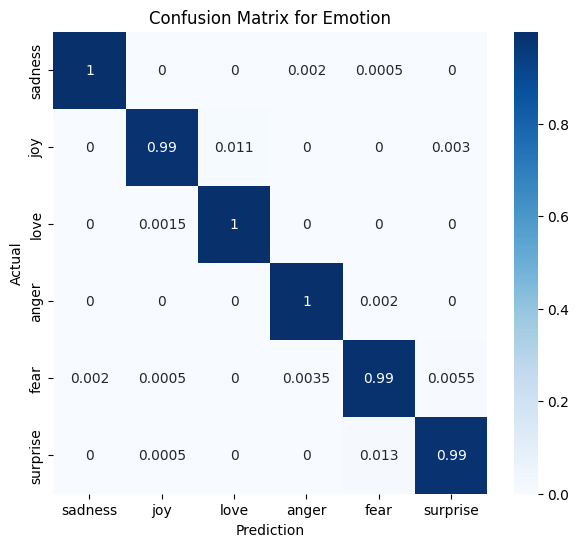

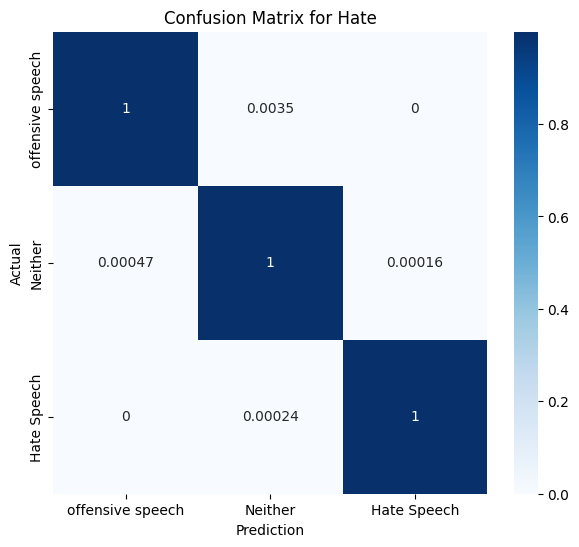

In [70]:
plot_cm(emotion_labels, emotion_pred, 'Confusion Matrix for Emotion', emotion_labels_text)
plot_cm(hate_labels, hate_pred, 'Confusion Matrix for Hate', hate_labels_text)

In [71]:
def classify_text(input_text):
    # Preprocess the input text
    input_text_cleaned = remove_stopwords(input_text)
    input_sequence = tokenizer.texts_to_sequences([input_text_cleaned])
    input_padded = pad_sequences(input_sequence, maxlen=max_length, padding='post')

    # Prediction (only Emotion and Hate)
    predictions = model.predict({
        'emotion_input': input_padded,
        'hate_input': input_padded
    })
    emotion_pred = np.argmax(predictions[0], axis=1)[0]
    hate_pred = np.argmax(predictions[1], axis=1)[0]

    # Determine major label (only Emotion and Hate)
    major_labels = ['Emotion', 'Hate']
    major_label_index = np.argmax([np.max(predictions[0]), np.max(predictions[1])])
    major_label = major_labels[major_label_index]

    # Sub-labels
    emotion_labels_text = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
    hate_labels_text = ['offensive speech', 'Neither', 'Hate Speech']

    if major_label == 'Emotion':
        sub_label = emotion_labels_text[emotion_pred]
    else:
        sub_label = hate_labels_text[hate_pred]

    return major_label, sub_label


In [72]:
import ipywidgets as widgets
from IPython.display import display

In [73]:
#define a text widget and a placeholder
input_text_widget = widgets.Text(
    description = 'Input text : ',
    placeholder = 'Enter you text'
)

In [74]:
#define classify button
button = widgets.Button(description = 'classify')

In [75]:
#define an output area to display result
output = widgets.Output()

In [76]:
#function to handle event
def on_button_click(b):
  with output:
    output.clear_output()   #clear the previous output
    input_text = input_text_widget.value
    major_label, sub_label = classify_text(input_text)
    print(f'Major Label : {major_label}')
    print(f'Sub Label : {sub_label}')

#attach the button at bottom
button.on_click(on_button_click)

In [77]:
display(input_text_widget, button, output)

Text(value='', description='Input text : ', placeholder='Enter you text')

Button(description='classify', style=ButtonStyle())

Output()